In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split



In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [3]:
df


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [4]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [6]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# HANDLING MISSING VALUES

In [7]:
categorical_columns = df.select_dtypes(include = ["object"]).columns
numerical_columns = df.select_dtypes(include = ["float64"]).columns

C:\Users\MRIGLIN SINGH\AppData\Local\Temp\ipykernel_30732\2876195880.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include = ["object"]).columns


In [8]:
categorical_columns

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [9]:
numerical_columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')

In [10]:
from sklearn.impute import SimpleImputer
numerical_imputer = SimpleImputer(strategy= "mean")
df[numerical_columns] = numerical_imputer.fit_transform(df[numerical_columns])


In [11]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [12]:
df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [13]:
categorical_imputer = SimpleImputer(strategy = "most_frequent")

In [14]:
df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

In [15]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

EDA

In [16]:
classes_count = df["Loan_Approved"].value_counts()

Text(0.5, 1.0, 'IS LOAN APPROVED OR NOT')

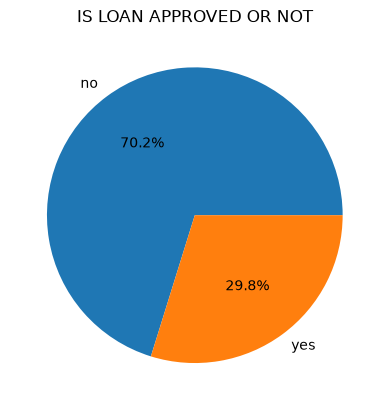

In [17]:
plt.pie(classes_count,
       labels = ["no","yes"],
       autopct = "%1.1f%%",
)
plt.title("IS LOAN APPROVED OR NOT")

In [18]:
classes_count

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

In [19]:
gender_count = df["Gender"].value_counts()

In [20]:
gender_count

Gender
Male      621
Female    379
Name: count, dtype: int64

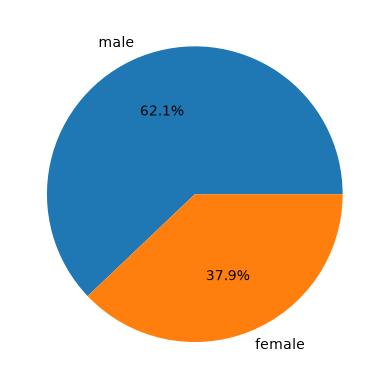

In [21]:
plt.pie(gender_count,
       labels= ["male","female"],
       autopct = "%1.1f%%")


In [22]:
education_level = df["Education_Level"].value_counts()

In [23]:
education_level

Education_Level
Graduate        722
Not Graduate    278
Name: count, dtype: int64

<Axes: xlabel='Education_Level', ylabel='count'>

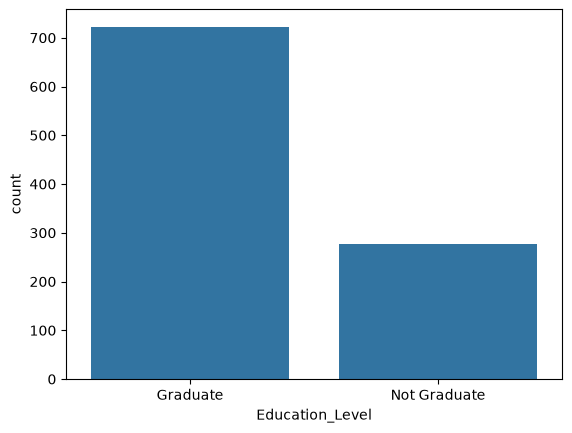

In [24]:
sns.barplot(education_level)

In [25]:
income = df["Applicant_Income"].value_counts()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

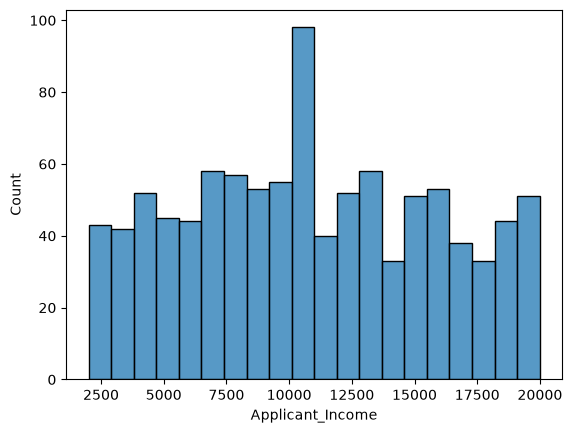

In [26]:
sns.histplot(data = df,
            x ="Applicant_Income",
            bins  = 20)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

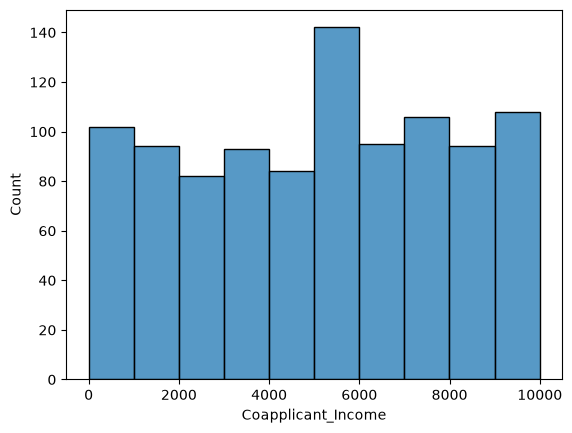

In [27]:
sns.histplot(data = df,
            x ="Coapplicant_Income",
            bins  = 10)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

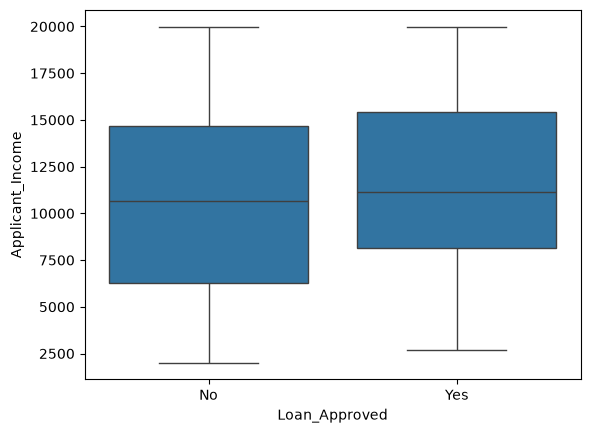

In [28]:
sns.boxplot(data = df,
           x = "Loan_Approved",
           y = "Applicant_Income")

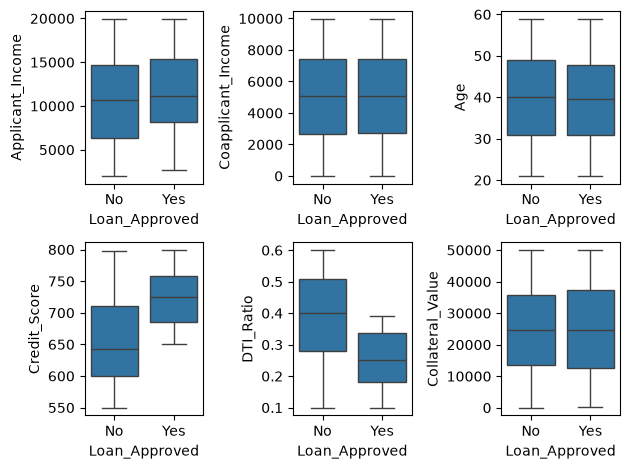

In [29]:
fig , axes = plt.subplots(2,3)
sns.boxplot(ax = axes[0,0],data = df,x = "Loan_Approved",y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df,x = "Loan_Approved",y = "Coapplicant_Income")
sns.boxplot(ax = axes[0,2],data = df,x = "Loan_Approved",y = "Age")
sns.boxplot(ax = axes[1,0],data = df,x = "Loan_Approved",y = "Credit_Score")
sns.boxplot(ax = axes[1,1],data = df,x = "Loan_Approved",y = "DTI_Ratio")
sns.boxplot(ax = axes[1,2],data = df,x = "Loan_Approved",y = "Collateral_Value")
plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

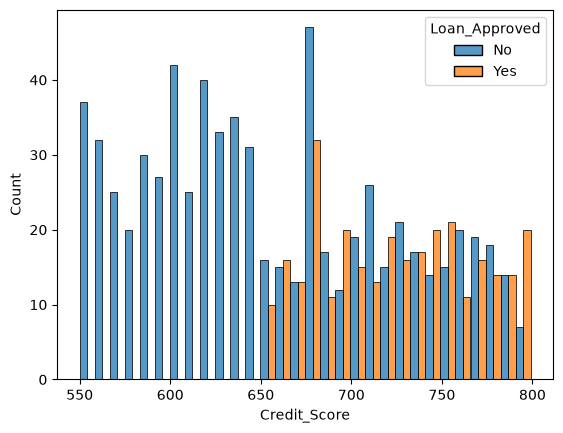

In [30]:
sns.histplot(data = df,x = "Credit_Score",hue = "Loan_Approved",bins = 30,multiple = "dodge")

In [31]:
df = df.drop(columns = "Applicant_ID")

encoding


In [32]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
label_encoder = LabelEncoder()
df["Loan_Approved"] = label_encoder.fit_transform(df["Loan_Approved"])

In [33]:
df["Education_Level"] = label_encoder.fit_transform(df["Education_Level"])




In [34]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [35]:
columns_for_onehotencoding = ["Employment_Status","Property_Area","Marital_Status","Loan_Purpose","Gender","Employer_Category"]

In [36]:
onehotencoder = OneHotEncoder(drop="first",sparse_output = False,handle_unknown = "ignore")
encoded = onehotencoder.fit_transform(df[columns_for_onehotencoding])
encoded_df = pd.DataFrame(encoded,columns = onehotencoder.get_feature_names_out(columns_for_onehotencoding),index = df.index)


In [37]:
df = pd.concat([df.drop(columns = columns_for_onehotencoding),encoded_df],axis = 1)

In [38]:
df

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved                   

In [40]:
no_columns = df.select_dtypes(include = "number")

In [41]:
correlation_matrix = no_columns.corr()

In [42]:
correlation_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.010057,-0.083398,0.032794,0.074209,-0.031234,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,-0.011431,-0.020148,0.028000,0.016022,0.059549,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,0.009162,-0.025521,-0.006283,0.029865,0.037293,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.011410,-0.043685,-0.044642,0.027343,-0.005785,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.056176,-0.030142,0.026013,-0.008658,0.015324,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,0.018010,-0.025228,-0.010035,0.001777,0.023212,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,-0.014850,-0.020907,0.040432,-0.014125,-0.036648,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,-0.004131,-0.009133,0.032558,-0.012217,-0.028948,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.018450,0.031112,0.040406,-0.050975,-0.007120,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,0.004683,-0.006788,-0.006119,-0.000930,0.032498,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [43]:
no_columns.corr()["Loan_Approved"].sort_values()

DTI_Ratio                         -0.444783
Loan_Amount                       -0.126499
Loan_Term                         -0.086644
Loan_Purpose_Car                  -0.056416
Gender_Male                       -0.054342
Education_Level                   -0.052920
Employment_Status_Unemployed      -0.044464
Employment_Status_Salaried        -0.041428
Employer_Category_Government      -0.039187
Existing_Loans                    -0.034794
Dependents                        -0.023811
Age                               -0.022343
Employer_Category_Unemployed      -0.021468
Loan_Purpose_Education            -0.016684
Savings                           -0.013437
Property_Area_Semiurban           -0.012967
Employer_Category_Private         -0.003347
Employment_Status_Self-employed   -0.001337
Loan_Purpose_Home                  0.002118
Coapplicant_Income                 0.004230
Collateral_Value                   0.021868
Property_Area_Urban                0.025963
Marital_Status_Single           

<Axes: >

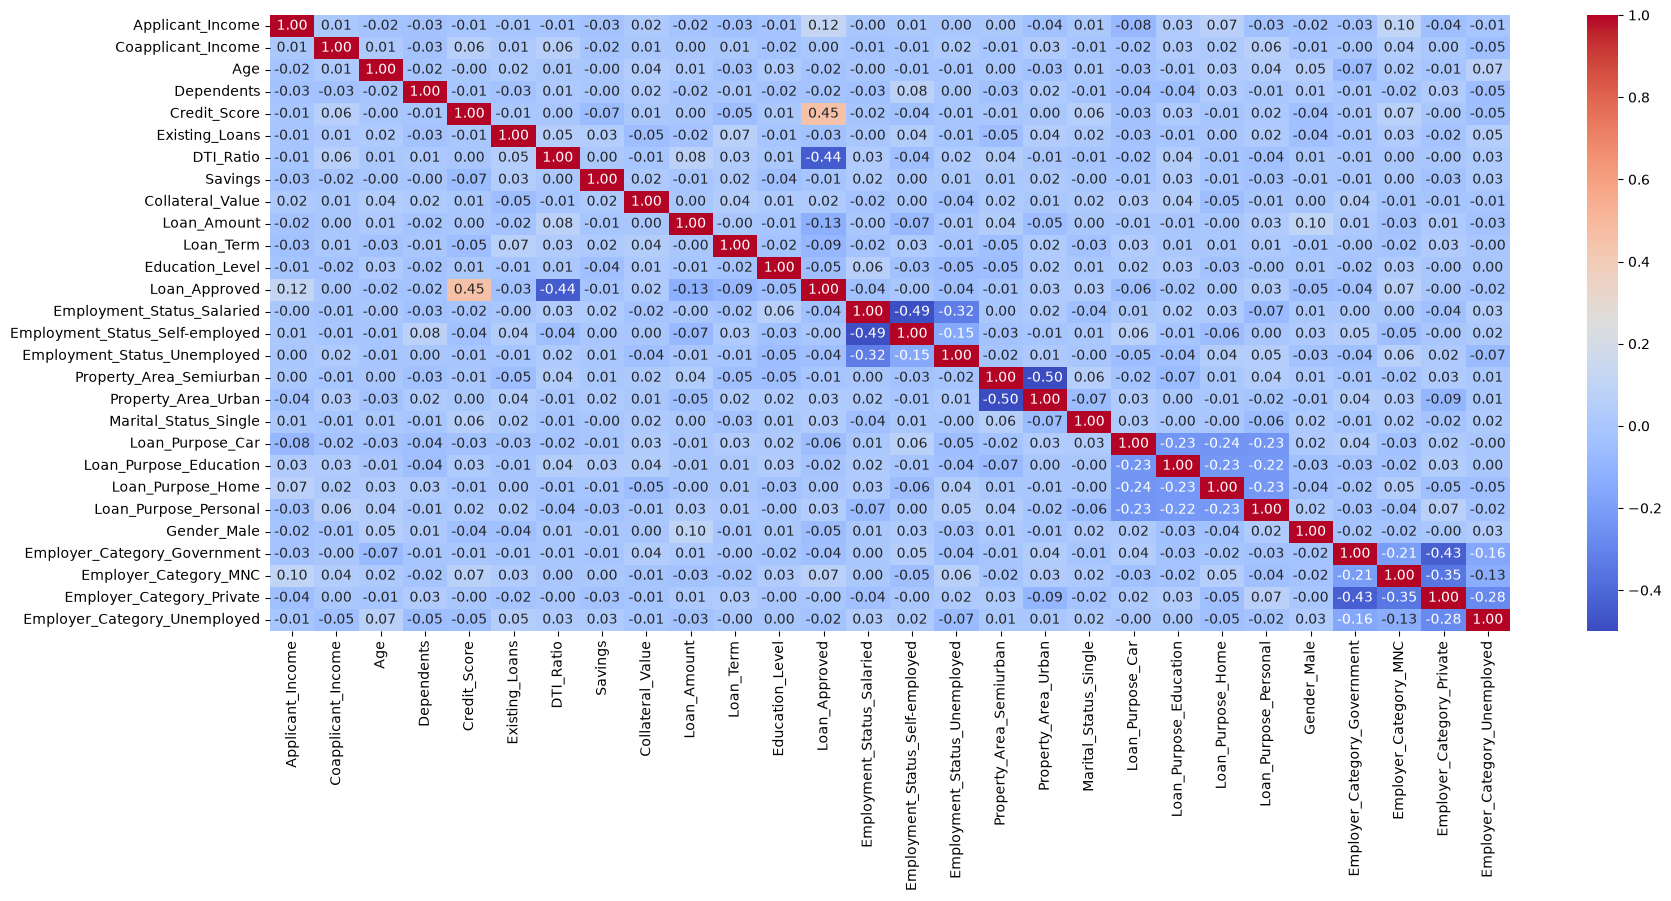

In [44]:
plt.figure(figsize = (20,8))
sns.heatmap(correlation_matrix,
           fmt=".2f",
            annot = True,
            cmap = "coolwarm")


In [45]:
X = df.drop(columns = "Loan_Approved")
Y = df["Loan_Approved"]


In [46]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state = 42)

In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#LOGISTIC REGRESSION

In [50]:
from sklearn.linear_model import LogisticRegression

In [51]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled,Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [52]:
y_pred = log_reg.predict(X_test_scaled) 

In [53]:
y_pred

array([0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0])

EVALUATION 


In [54]:
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,confusion_matrix

In [59]:
print("LOGISTIC REGRESSION"),
print("precision :",precision_score(Y_test,y_pred)),
print("accuracy :",accuracy_score(Y_test,y_pred)),
print("f1 :",f1_score(Y_test,y_pred)),
print("recall :",recall_score(Y_test,y_pred))
print("confsuion matrix :",confusion_matrix(Y_test,y_pred))

LOGISTIC REGRESSION
precision : 0.7833333333333333
accuracy : 0.865
f1 : 0.7768595041322314
recall : 0.7704918032786885
confsuion matrix : [[126  13]
 [ 14  47]]


KNN

In [74]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=13)
knn.fit(X_train_scaled,Y_train)
Y_pred = knn.predict(X_test_scaled)
print("KNN"),
print("precision :",precision_score(Y_test,Y_pred)),
print("accuracy :",accuracy_score(Y_test,Y_pred)),
print("f1 :",f1_score(Y_test ,Y_pred)),
print("recall :",recall_score(Y_test,Y_pred))
print("confsuion matrix :",confusion_matrix(Y_test,Y_pred))


KNN
precision : 0.7317073170731707
accuracy : 0.79
f1 : 0.5882352941176471
recall : 0.4918032786885246
confsuion matrix : [[128  11]
 [ 31  30]]


In [75]:
from sklearn.naive_bayes import GaussianNB
naivebayes = GaussianNB()
naivebayes.fit(X_train_scaled,Y_train)
y_predict = naivebayes.predict(X_test_scaled)

print("naive bayes"),
print("precision :",precision_score(Y_test,y_predict)),
print("accuracy :",accuracy_score(Y_test,y_predict)),
print("f1 :",f1_score(Y_test ,y_predict)),
print("recall :",recall_score(Y_test,y_predict))
print("confsuion matrix :",confusion_matrix(Y_test,y_predict))


naive bayes
precision : 0.8035714285714286
accuracy : 0.865
f1 : 0.7692307692307693
recall : 0.7377049180327869
confsuion matrix : [[128  11]
 [ 16  45]]


FEATURE ENGINEERING


In [86]:
df["Credit_score_sq"] = df["Credit_Score"]**2
df["DTI_Ratio_sq"] = df["DTI_Ratio"]**2
x = df.drop(columns = ["Credit_Score","DTI_Ratio","Loan_Approved"])
y = df["Loan_Approved"]

In [87]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [88]:
SCALER = StandardScaler()
x_train_scaled = SCALER.fit_transform(x_train)
x_test_scaled = SCALER.transform(x_test)


In [89]:
log_reg_fe = LogisticRegression()
log_reg_fe.fit(x_train_scaled,y_train)
y_pred_fe = log_reg_fe.predict(x_test_scaled) 

In [90]:
print("LOGISTIC REGRESSION"),
print("precision :",precision_score(y_test,y_pred_fe)),
print("accuracy :",accuracy_score(y_test,y_pred_fe)),
print("f1 :",f1_score(y_test,y_pred_fe)),
print("recall :",recall_score(y_test,y_pred_fe))
print("confsuion matrix :",confusion_matrix(y_test,y_pred_fe))

LOGISTIC REGRESSION
precision : 0.7846153846153846
accuracy : 0.88
f1 : 0.8095238095238095
recall : 0.8360655737704918
confsuion matrix : [[125  14]
 [ 10  51]]


In [94]:
knn_fe = KNeighborsClassifier(n_neighbors=13)
knn_fe.fit(x_train_scaled,y_train)
y_pred_fe_knn = knn_fe.predict(x_test_scaled)
print("KNN"),
print("precision :",precision_score(y_test,y_pred_fe_knn)),
print("accuracy :",accuracy_score(y_test,y_pred_fe_knn)),
print("f1 :",f1_score(y_test ,y_pred_fe_knn)),
print("recall :",recall_score(y_test,y_pred_fe_knn))
print("confsuion matrix :",confusion_matrix(y_test,y_pred_fe_knn))


KNN
precision : 0.6744186046511628
accuracy : 0.77
f1 : 0.5576923076923077
recall : 0.47540983606557374
confsuion matrix : [[125  14]
 [ 32  29]]


In [95]:
naivebayes_fe = GaussianNB()
naivebayes_fe.fit(x_train_scaled,y_train)
y_predict_fe_nb = naivebayes_fe.predict(x_test_scaled)

print("naive bayes"),
print("precision :",precision_score(y_test,y_predict_fe_nb)),
print("accuracy :",accuracy_score(y_test,y_predict_fe_nb)),
print("f1 :",f1_score(y_test ,y_predict_fe_nb)),
print("recall :",recall_score(y_test,y_predict_fe_nb))
print("confsuion matrix :",confusion_matrix(y_test,y_predict_fe_nb))


naive bayes
precision : 0.8113207547169812
accuracy : 0.86
f1 : 0.7543859649122807
recall : 0.7049180327868853
confsuion matrix : [[129  10]
 [ 18  43]]


CONCLUSION - Naive Bayes turned out to be the best model for this case as precision score was the governing factor